<a href="https://colab.research.google.com/github/P17saxena/Production-Decline-Analysis-Reserve-Estimation/blob/main/Production_Decline_Analysis_%26_Reserves_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production Decline Analysis & Reserves Estimation

Fits three Arps decline models (exponential, harmonic, hyperbolic) to well production data, statistically selects the best-fitting model (R² and AIC), forecasts EUR (Estimated Ultimate Recovery), and cross-checks that result against an independent volumetric OOIP estimate using Monte Carlo simulation (P10/P50/P90).

## 1. Imports Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
np.random.seed(42)  # fixes randomness so this notebook reproduces identical results every run

## 2. Synthetic data production

In [ ]:
# moderate-rate onshore well.
true_qi = 850   # initial rate, barrels of oil per day (bopd)
true_Di = 0.045 # initial nominal decline rate (per month)
true_b  = 0.6   # hyperbolic exponent (0 = exponential, 1 = harmonic, between = hyperbolic)

n_months=36                         #number of months data
t_data= np.arange(1,n_months+1)     # series of months

q_true= true_qi/((1+ true_b*true_Di*t_data)**(1/true_b)) # find series of q data using hyperbolic as we assumed it to be it

noise= np.random.normal(0,0.04,size=n_months)*q_true
q_data= q_true+ noise
df= pd.DataFrame({"Month":t_data, "Oil_Rate":(q_data)})

df.head() #display starting values

,Month,Oil_Rate
0,1,829.237740
1,2,774.359583
2,3,765.862829
3,4,760.097173
4,5,681.824067


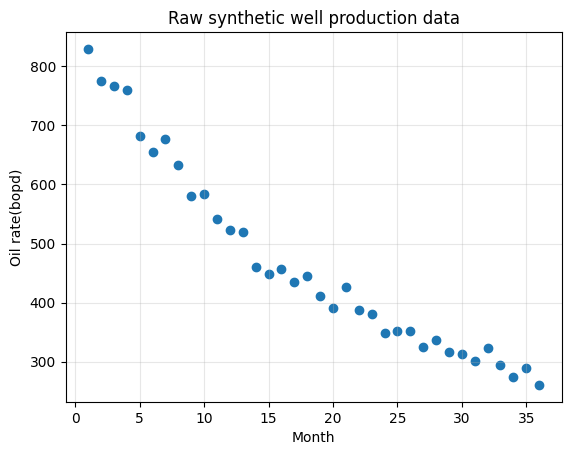

In [5]:
# Plot of raw data
plt.figure
plt.scatter(df["Month"],df["Oil_Rate"])
plt.xlabel("Month")
plt.ylabel("Oil rate(bopd)")
plt.title("Raw synthetic well production data")
plt.grid(alpha=0.3)

plt.show()

## 3. The three Arps decline equations

| Model | Equation | b value |
|---|---|---|
| Exponential | `q(t) = qi * exp(-Di * t)` | b = 0 |
| Harmonic | `q(t) = qi / (1 + Di * t)` | b = 1 |
| Hyperbolic | `q(t) = qi / (1 + b*Di*t)^(1/b)` | 0 < b < 1 |



In [ ]:
def exponential(t,qi,Di):
    return qi* np.exp(-Di*t)

def hyperbolic(t,qi,Di,b):
    return qi/((1+ Di*b*t)**(1/b))

def harmonic(t,qi,Di):
 return qi/(1+ (Di*t))

## 4. Fit each model on data : Curve Fitting



In [ ]:
# Create reasonable starting guesses for the computer to begin its search
guess_for_2_params = [q_data[0], 0.05]
guess_for_3_params = [q_data[0], 0.05, 0.5]

# 1. Fit Exponential Model
popt_exp, _ = curve_fit(exponential, df["Month"],df["Oil_Rate"], p0=guess_for_2_params)
qi_exp = popt_exp[0]
Di_exp = popt_exp[1]

# 2. Fit Harmonic Model
popt_harm, _ = curve_fit(harmonic, df["Month"],df["Oil_Rate"], p0=guess_for_2_params)
qi_harm = popt_harm[0]
Di_harm = popt_harm[1]

# 3. Fit Hyperbolic Model (we limit 'b' between 0.01 and 1.99 to keep it realistic)
popt_hyp, _ = curve_fit(hyperbolic, df["Month"],df["Oil_Rate"], p0=guess_for_3_params, bounds=([0, 0, 0.1], [np.inf, np.inf, 1.99]))
qi_hyp = popt_hyp[0]
Di_hyp = popt_hyp[1]
b_hyp = popt_hyp[2]

print("Curve matching complete!")
print()
print(f"Exponential : qi={qi_exp:.2f}, Di={Di_exp:.4f}")
print(f"Harmonic    : qi={qi_harm:.2f}, Di={Di_harm:.4f}")
print(f"Hyperbolic  : qi={qi_hyp:.2f}, Di={Di_hyp:.4f}")

Curve matching complete!

Exponential : qi=820.77, Di=0.0337
Harmonic    : qi=903.73, Di=0.0613
Hyperbolic  : qi=880.17, Di=0.0515


## 5. Picking the best-fit model (R² and AIC)

In [ ]:
#define r2 and aic functions
def r2(actual,predicted):
    error_squared= np.sum((actual-predicted)**2)
    variance_squared= np.sum((actual-np.mean(actual))**2)
    return (1-(error_squared/variance_squared))


def aic(actual,predicted,no_of_para):
    error_squared= np.sum((actual-predicted)**2)
    n=len(actual)
    return n*np.log(error_squared /n )+ 2* no_of_para


#generate the predicted values of q via all three methods
q_pred_expo= exponential(df["Month"],qi_exp,Di_exp)
q_pred_harm= harmonic(df["Month"],qi_harm,Di_harm)
q_pred_hyper= hyperbolic(df["Month"],qi_hyp,Di_hyp,b_hyp)


In [ ]:
#do r2 and aic check for best fit

#r2 find
r2_exp= r2(q_data,q_pred_expo)
r2_harm=r2(q_data,q_pred_harm)
r2_hyper=r2(q_data,q_pred_hyper)

#aic find
aic_exp= aic(q_data,q_pred_expo,2)
aic_harm=aic(q_data,q_pred_harm,2)
aic_hyper=aic(q_data,q_pred_hyper,3)

results=pd.DataFrame({"Models":["Exponential","Harmonic","Hyperbolic"],
                      "r2":[r2_exp,r2_harm,r2_hyper],
                      "aic":[aic_exp,aic_harm,aic_hyper]})

resultant_aic= results["aic"].idxmin() #find the best aic that is the min one

best_model= results.loc[resultant_aic,"Models"]

print(results)
print()
print("The Best Model:",best_model)

        Models        r2         aic
0  Exponential  0.978089  232.236248
1     Harmonic  0.988291  209.677394
2   Hyperbolic  0.989990  206.034425

The Best Model: Hyperbolic


## 6. Plot all three fits against the actual data

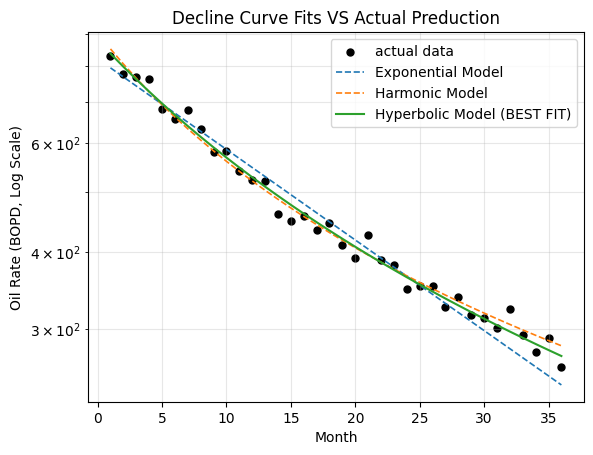

In [ ]:
plt.figure
plt.scatter(t_data, q_data,color="black",s=25,label="actual data")
plt.plot(t_data, q_pred_expo,linestyle="--", linewidth=1.2, label="Exponential Model")
plt.plot(t_data, q_pred_harm,linestyle="--", linewidth=1.2, label="Harmonic Model")
plt.plot(t_data, q_pred_hyper,label="Hyperbolic Model (BEST FIT)")

plt.yscale("log")
plt.xlabel("Month")
plt.ylabel("Oil Rate (BOPD, Log Scale)")
plt.title("Decline Curve Fits VS Actual Preduction")

plt.legend()
plt.grid(alpha=0.3, which="both")                 # Clean, non-distracting background grid lines
plt.show()

## 7. Forecast EUR (Estimated Ultimate Recovery)

In [ ]:
t_future =np.arange(1,601)  #predicting future production till 50 years (600 minths)

#choose model to predict
if best_model=="Exponential":
    q_forecast=exponential(t_future, qi_exp, Di_exp)
elif best_model=="Harmonic":
    q_forecast=harmonic(t_future, qi_harm, Di_harm)
elif best_model=="Hyperbolic":
    q_forecast=hyperbolic(t_future, qi_hyp, Di_hyp,b_hyp)


#filter values below economic limit=5
economic_limit=5
q_forecast_trim= q_forecast[q_forecast> economic_limit]
t_forecast_trim= t_future[q_forecast> economic_limit]

month_days= 30.4                                   #days in a month as production given in bbl/month unit

cumulative_prod=np.sum(q_data)*30.4               #cumulative is calculated from original data
remaining_prod= np.sum(q_forecast[36:])* 30.4     #remaining production from month 37 onward (index 36 = month 37)

EUR= remaining_prod + cumulative_prod

print("EUR                  :",EUR,"bbls")
print("Cumulative Production:",cumulative_prod,"bbls")
print("Remaining Production :"  ,remaining_prod,"bbls")


EUR                  : 1298272.4901477764 bbls
Cumulative Production: 512289.0548244245 bbls
Remaining Production : 785983.4353233519 bbls


## 8. Volumetric OOIP via Monte Carlo (the independent cross-check)

Formula: `OOIP = 7758 * A * h * φ * (1 - Sw) / Boi`

### P10 / P50 / P90

- **P50** = median : the "most likely"/"best" estimate.
- **P90** = a conservative, low-side estimate (90% of outcomes were *at least* this
  much).
- **P10** = an optimistic, high-side estimate (only 10% of outcomes were this high or
  higher).

In [ ]:
# Set the number of trial runs for our simulation
simulations = 10000

# Generate the random reservoir properties based on uncertainity ranges
area= np.random.triangular(400,640,900, simulations)     # acres(min,mode, max)
height=np.random.triangular(20,30,45,simulations)        #feet
phi = np.random.triangular(0.02,0.18,0.35, simulations)
Sw =np.random.triangular(0.05,0.30,0.50,simulations)
boi= 1.2

#calculate OOIP distribution in graph
OOIP_distribution= 7758* area* height * phi *(1-Sw)/ boi

#confidence levels using percentiles
p90 = np.percentile(OOIP_distribution,10)      # LOW :90% chance the reservoir has at least this much oil
p10 = np.percentile(OOIP_distribution,90)      # HIGH :Only a 10% chance the reservoir has this much oil
p50 = np.percentile(OOIP_distribution,50)

print(f"OOIP P90 (conservative):", p90,"bbls")
print(f"OOIP P50 (most likely) :", p50,"bbls")
print(f"OOIP P10 (optimistic)  :", p10,"bbls")

OOIP P90 (conservative): 7901236.982792211 bbls
OOIP P50 (most likely) : 16378281.304995686 bbls
OOIP P10 (optimistic)  : 28064408.124181956 bbls


## 9. Recovery factor

In [ ]:
#RECOVERY FACTOR
RF = EUR/p50 *100
print("Recovery Factor:", RF, "%")

Recovery Factor: 7.926793208465523 %


## 10. Summary table

Everything pulled into one place

In [ ]:
# Pull the winning model's own parameters (not always hyperbolic!)
if best_model == "Exponential":
    qi_best, Di_best, b_best = qi_exp, Di_exp, "N/A (b=0 by definition)"
elif best_model == "Harmonic":
    qi_best, Di_best, b_best = qi_harm, Di_harm, "N/A (b=1 by definition)"
else:
    qi_best, Di_best, b_best = qi_hyp, Di_hyp, f"{b_hyp:.3f}"

summary = pd.DataFrame({
    "Metric": [ "Best-fit decline model",
               "qi (bopd)", "Di (per month)",
               "b (if hyperbolic)",
               "EUR (bbl)",
               "Cumulative produced to date (bbl)",
               "Remaining reserves (bbl)",
               "OOIP P90 (bbl)",
               "OOIP P50 (bbl)",
               "OOIP P10 (bbl)",
               "Recovery Factor"
    ],
     "Value": [
        best_model,
        f"{qi_best:.2f}",
        f"{Di_best:.4f}" if isinstance(Di_best, float) else Di_best,
        b_best,
        f"{EUR:,.0f}",
        f"{cumulative_prod:,.0f}",
        f"{remaining_prod:,.0f}",
        f"{p90:,.0f}",
        f"{p50:,.0f}",
        f"{p10:,.0f}",
        f"{RF:.1f}%",
    ]})
summary

,Metric,Value
0,Best-fit decline model,Hyperbolic
1,qi (bopd),880.17
2,Di (per month),0.0515
3,b (if hyperbolic),0.721
4,EUR (bbl),"1,298,272"
5,Cumulative produced to date (bbl),"512,289"
6,Remaining reserves (bbl),"785,983"
7,OOIP P90 (bbl),"7,901,237"
8,OOIP P50 (bbl),"16,378,281"
9,OOIP P10 (bbl),"28,064,408"
